# Pr-YBCO version Fit modes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from importlib import reload
import C2_alris_one_third_functions as C2_alris_one_third_functions
reload(C2_alris_one_third_functions)
from C2_alris_one_third_functions import shift_atoms, transform_list_hkl_p63_p65, get_structure_factors , atom_position_list
from matplotlib.markers import MarkerStyle
from time import time

tf.keras.utils.set_random_seed(1)

Define the function containing the fitting parameters

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- `fun_tf()` correspond to the **structure factor calculation function** (one has to convert it to a **TF-compatible** function)
- <span style="color:red">If conversion to TF-compatible function is not possible, then this approach will probably not work (or becomes much more tedious at least)</span>

In [2]:
def fn_all_hkl_list():
    all_h_list = np.linspace(0 , -4.666666 , 15)
    all_k_list = np.linspace(0 , 4.666666 , 15) 
    all_l_list = np.linspace(0 , 12 , 5) 
    all_hkl_list = np.array(np.meshgrid(all_h_list, all_k_list, all_l_list)).T.reshape(-1, 3)
    all_hkl_list = tf.convert_to_tensor(all_hkl_list, dtype=tf.float32)
    return all_hkl_list

In [3]:
def make_hkl_indices(hkl_list , experimental_data):

    
    hkl_list = np.array(hkl_list, dtype=np.float32) * 3
    hkl_list = pd.DataFrame(hkl_list, columns=['h', 'k', 'l'])

    #turn all values into integers
    hkl_list = hkl_list.astype(int)

    print('hkl')
    print(hkl_list)
    print('hkl_list shape')
    print(hkl_list.shape)

    all_h_list = np.linspace(0 , -4.666666 , 15) * 3
    all_k_list = np.linspace(0 , 4.666666 , 15) * 3
    all_l_list = np.linspace(0 , 12 , 5) * 3
    all_hkl_list = np.array(np.meshgrid(all_h_list, all_k_list, all_l_list)).T.reshape(-1, 3)
    all_hkl_list = np.round(all_hkl_list).astype(int)
    all_hkl_list = pd.DataFrame(all_hkl_list, columns=['h', 'k', 'l'])


    # all_hkl_list = all_hkl_list.astype(int)
    print('all_hkl')
    print(all_hkl_list)

    merged = all_hkl_list.merge(hkl_list, how='left', indicator=True)
    hkl_indices = merged[merged['_merge'] == 'both'].index.tolist()

    print('hkl_indices')
    print(hkl_indices)

    #retrive hkl values from all_hkl_list using hkl_indices
    hkl_from_indices = all_hkl_list.iloc[hkl_indices].values.tolist()

    print('hkl_from_indices')
    print(hkl_from_indices)

    reordered_hkl_list = pd.DataFrame(hkl_from_indices, columns=['h', 'k', 'l'])


    experimental_data[['h', 'k', 'l']] = experimental_data[['h', 'k', 'l']] * 3 
    experimental_data[['h', 'k', 'l']] = np.round(experimental_data[['h', 'k', 'l']]).astype(int)

    print('reordered_hkl_list')
    print(reordered_hkl_list)

    print('hkl_indices')
    print(hkl_indices)

    print('hkl_indices length')
    print(len(hkl_indices))

    #find the intensity values from experimental_data corresponding to the reordered_hkl_list
    intensity = []
    for index, row in reordered_hkl_list.iterrows():
        h = row['h']
        k = row['k']
        l = row['l']
        intensity_value = experimental_data[(experimental_data['h'] == h) & (experimental_data['k'] == k) & (experimental_data['l'] == l)]['intensity_exp'].values
        print('intensity_value')
        print(intensity_value)
        
        if len(intensity_value) > 0:
            intensity.append(intensity_value[0])
        else:
            intensity.append(0)

    reordered_hkl_list = np.array(hkl_from_indices, dtype=np.float32) / 3

    return hkl_indices , reordered_hkl_list , intensity

In [4]:
mode_num = 102
structure_type = 'C2'

path = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type

# experimental_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no0.csv')
experimental_data2 = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no_bragg.csv')

hkl_list = experimental_data2[["h", "k", "l"]].values.tolist()

print('hkl_list')
print(hkl_list)


hkl_indices , hkl_list , intensity_reordered = make_hkl_indices(hkl_list , experimental_data2)
experimental_data = pd.DataFrame(hkl_list , columns=['h', 'k', 'l'])
experimental_data['intensity_exp'] = intensity_reordered

print('reordered hkl_list')
print(hkl_list)

hkl_list = tf.convert_to_tensor(hkl_list, dtype=tf.float32)


path_matrix = path + '/C2_matrix.txt'
matrix = np.loadtxt(path_matrix, dtype=np.float32)
matrix = tf.convert_to_tensor(matrix, dtype=tf.float32)

hkl_list
[[-0.333333333, 1.0, 0.0], [-0.666666667, 1.0, 0.0], [-1.333333333, 1.0, 0.0], [-2.333333333, 1.0, 0.0], [-2.666666667, 1.0, 0.0], [-3.333333333, 1.0, 0.0], [-3.666666667, 1.0, 0.0], [-4.333333333, 1.0, 0.0], [-4.666666667, 1.0, 0.0], [-1.0, 1.333333333, 0.0], [-3.0, 1.333333333, 0.0], [-2.0, 1.666666667, 0.0], [-4.0, 1.666666667, 0.0], [-0.333333333, 2.0, 0.0], [-1.666666667, 2.0, 0.0], [-2.333333333, 2.0, 0.0], [-2.666666667, 2.0, 0.0], [-3.333333333, 2.0, 0.0], [-3.666666667, 2.0, 0.0], [-0.666666667, 2.333333333, 0.0], [-1.0, 2.333333333, 0.0], [-2.0, 2.333333333, 0.0], [-3.0, 2.333333333, 0.0], [-4.0, 2.333333333, 0.0], [-1.0, 2.666666667, 0.0], [-2.0, 2.666666667, 0.0], [-3.0, 2.666666667, 0.0], [-1.333333333, 3.0, 0.0], [-2.333333333, 3.0, 0.0], [-2.666666667, 3.0, 0.0], [-3.333333333, 3.0, 0.0], [-4.333333333, 3.0, 0.0], [-4.666666667, 3.0, 0.0], [-1.0, 3.333333333, 0.0], [-2.0, 3.333333333, 0.0], [-3.0, 3.333333333, 0.0], [-4.0, 3.333333333, 0.0], [-2.0, 3.666666667, 

Sample the "training data" (features and labels)

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The features are the (h,k,l) coordinates (e.g. a vector of size `n_features` x 3, i.e. `n_dim = 3`)
- Maybe one has to normalize the features (i.e. not using integers but floats between -1 (0) and 1)? Before passing them to the structure calculation function, they should be again rescaled to integers
- The labels would be the experimental intensities (again, maybe have to be normalized to the range between 0 and 1)

Max label ERR: 20.065367
min label ERR: 0.01616863
Features shape: (302, 3)
Labels shape: (302, 1)
error shape: (302, 1)
Max label: 61.84816
min label : 0.049837116


(array([191.,  63.,  20.,  14.,   5.,   3.,   3.,   0.,   1.,   0.,   1.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.]),
 array([ 0.        ,  1.26220734,  2.52441469,  3.78662203,  5.04882937,
         6.31103671,  7.57324406,  8.8354514 , 10.09765874, 11.35986608,
        12.62207343, 13.88428077, 15.14648811, 16.40869545, 17.6709028 ,
        18.93311014, 20.19531748, 21.45752483, 22.71973217, 23.98193951,
        25.24414685, 26.5063542 , 27.76856154, 29.03076888, 30.29297622,
        31.55518357, 32.81739091, 34.07959825, 35.34180559, 36.60401294,
        37.86622028, 39.12842762, 40.39063496, 41.65284231, 42.91504965,
        44.17725699, 45.43946434, 46.70167168, 47.96387902, 49.22608636,
        50.48829371, 51.75050105, 53.01270839, 54.27491573, 55.53712308,
       

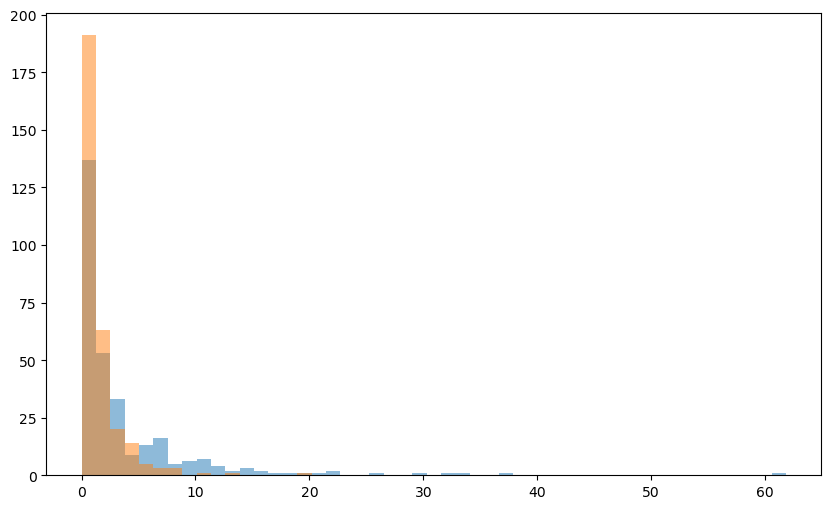

In [12]:
n_features = experimental_data.shape[0]
n_dim = 3

features = hkl_list
labels = experimental_data["intensity_exp"].tolist()
vol_err = experimental_data2["intensity_exp_err"].tolist()

#labels = np.array(labels, dtype=np.float32)
#labels = labels / np.max(labels) #Normalize labels
#labels = labels / 149709.010190213 * 100  # Normalize to sum to 60

labels_err = []

for label, err in zip(labels, vol_err):
    if label == 0:
        labels_err.append(1e-9)  # Assign a high error for zero labels
    else:
        labels_err.append(1/label)
        # labels_err.append((label**3)  ) # Normalize error to sum to 60
        #labels_err.append(np.abs((5000 - (1/label * 100))))  # Inverse error for each label

labels_tgt = [labels, labels_err]
labels_tgt = np.transpose(labels_tgt)
labels_err = tf.convert_to_tensor(labels_err, dtype=tf.float32)
labels = tf.convert_to_tensor(labels, dtype=tf.float32)

labels = tf.expand_dims(labels, axis=-1)  # Ensure labels are 2D
labels_err = tf.expand_dims(labels_err, axis=-1)  # Ensure labels_err are 2D

print("Max label ERR:", np.max(labels_err))
print("min label ERR:", np.min(labels_err))
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
print('error shape:', labels_err.shape)
print("Max label:", np.max(labels))
print("min label :", np.min(labels))
#bin from0 to 0.0025 with 50 bins
plt.figure(figsize=(10, 6))

plt.hist(labels.numpy(), bins=np.linspace(0 , np.max(labels) , 50), alpha=0.5, label='Labels')
plt.hist(labels_err.numpy(), bins=np.linspace(0 , np.max(labels) , 50), alpha=0.5, label='Labels Error')


In [13]:
def fun_tf(hkl_list, pars, matrix):
    """
    Fast computation of structure factors with parameter-dependent structure.
    """
    # stack parameters
    pars_tensor = tf.stack(pars)  # shape (params,)

    atom_shift_list = shift_atoms(matrix , (pars_tensor))
    atom_shift_list = atom_shift_list[:,0]
    atom_shift_list = tf.unstack(atom_shift_list)

    modified_struct = atom_position_list(*atom_shift_list)
    all_hkl_list = fn_all_hkl_list()
    all_hkl_list = transform_list_hkl_p63_p65(all_hkl_list)

    # Get structure factors
    sf_hkl = get_structure_factors(all_hkl_list, modified_struct)
    intensity = (abs(sf_hkl)) ** 2

    w = tf.constant(0.000811509257682975, dtype=tf.float32)  # Debye-Waller factor 
    qnorms = tf.norm(tf.cast(all_hkl_list, tf.float32), axis=1)
    intensity = intensity * tf.exp(- w * qnorms ** 2)  # Apply Debye-Waller factor

    all_sim_intensity = intensity * 100
    #sim_intensity = intensity / tf.reduce_max(intensity)  # Normalize to max intensity
    # print(tf.reduce_sum(all_sim_intensity))

    # all_sim_intensity = all_sim_intensity / tf.reduce_sum(all_sim_intensity) * 100

    # Extract only the intensities corresponding to the input hkl_list
    sim_intensity = tf.gather(all_sim_intensity, hkl_indices)

    print(len(sim_intensity))

    return sim_intensity

Define a simple model

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The six parameters (a,b,c,d,e,f) correspond to the fractional atomic shifts in the modes w.r.t. unit cell lengths
- Instead of `sigmoid`, `tanh` should be applied to the parameters before passing them to the structure factor calculation function (ensures smoother gradient landscape)
- The `tanh` function can furthermore be limited to a specific range (e.g. if atomic distortions should not exceed +- 0.1)

In [14]:
class FunAsLayer(tf.keras.layers.Layer):
    def __init__(self, matrix , max_mode_amps,**kwargs):
        super().__init__(**kwargs)
        self.max_mode_amps = max_mode_amps
        self.matrix = matrix

    def build(self, input_shape):
        self.param = self.add_weight(name='param', shape=(mode_num,), initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.04, seed=1), trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        # Apply tanh to ensure parameters stay within the [-1, 1] range then multiply by max_mode_amps so each parameter is scaled corresponding to the element in max_mode_amps
        pretransform = tf.tanh(self.param) 
        transformed_params = pretransform * self.max_mode_amps  # Scale parameters

        output = fun_tf(inputs, transformed_params , self.matrix)
        return tf.reshape(output , [-1])  # Ensure output is 1D




Create optimizer and define loss function

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The learning rate must be determined by experimentation (same holds for the batch size and the number of epochs below)
- As a loss function, one can try either MSE or R-score (MSE seems to be the more "natural choice" in this case)

In [15]:
"""
# R-Score based on intensity
class RFactorLoss(tf.keras.losses.Loss):
    def call(self, y_true, y_pred):
        return tf.reduce_sum(tf.abs(y_true - y_pred)) / tf.reduce_sum(y_true)
"""
    
# mean squared error
class PerSampleMSELoss(tf.keras.losses.Loss):
    def __init__(self, tf_bragg_indices):
        self.tf_bragg_indices = tf_bragg_indices
        super().__init__(reduction=tf.keras.losses.Reduction.NONE)

    def call(self, y_true, y_pred):
        #retrieve y_pred values at bragg indices
        print('y_pred shape:', y_pred.shape)
        if y_pred.shape != (None,):
            y_pred_bragg = tf.gather(y_pred, self.tf_bragg_indices)
            # y_true = tf.expand_dims(y_true, axis=-1)

            print('before update loss y_true')
            print("y_pred_bragg shape:", y_pred_bragg.shape)
            print("y_true shape:", y_true.shape)
            print("tf_bragg_indices shape:", self.tf_bragg_indices.shape)


            # let squared error be zero for bragg indices
            y_true_loss = tf.tensor_scatter_nd_update(y_true , self.tf_bragg_indices , y_pred_bragg)
            print('updated loss y_true')
            print("y_true_loss shape:", y_true_loss.shape)
            y_true_loss = tf.squeeze(y_true_loss, axis=-1)
            print("y_true_loss shape after squeeze:", y_true_loss.shape)
        else:
            y_true_loss = y_true
            print('not updated loss y_true')

        squared_error = tf.square(y_true_loss - y_pred)
        per_sample_mse = tf.reduce_mean(squared_error, axis=-1)
        return per_sample_mse  # shape (batch_size,)

class WeightedMeanSquaredError(tf.keras.losses.Loss):
    def __init__(self,reduction=tf.keras.losses.Reduction.AUTO, name='WeightedMeanSquaredError'):
        super(WeightedMeanSquaredError, self).__init__(reduction=reduction, name=name)

    def call(self, y_true, y_pred):
        mse = tf.keras.losses.mean_squared_error(y_true, y_pred)
        return mse

    def num_of_elements(self, sample_weight):
        return tf.size(sample_weight).numpy()
    
    def __call__(self, y_true, y_pred,sample_weight):
        #return super().__call__(y_true, y_pred, 1)
        # 1/n *  sum(weights * mse(y_p - y_t))
        actual_loss = super().__call__(y_true, y_pred)
        num_of_el = tf.py_function(func=self.num_of_elements, inp = [sample_weight], Tout=tf.float32)

        # dividing by sum of all weights in this batch
        # (sum(weights * mse(y_p - y_t))) / sum(weights)
        wmse_loss = actual_loss * (num_of_el / tf.math.reduce_sum(sample_weight))
        return wmse_loss
  

# Define the custom metric function
def r_factor_metric(y_true, y_pred):
    labels = y_true
    print('r_factor_metric called')
    return tf.reduce_sum(tf.abs(labels - y_pred)) / tf.reduce_sum(tf.abs(labels))


Train the model for n iterations (to try different initial weights)

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The number of iterations defines the "starting position" $w_0$ of the gradient descent algorithm
- Because there are probably many local minima, changing $w_0$ allows the algorithm to find different minima and increases the chances of finding the global minima

Learning rate: 4e-05
302
302
r_factor_metric called
302
r_factor_metric called
(102,)
Final loss: 2.454e+11
302
r_factor_metric called
Iteration 1 - New best loss: 2.454e+11 (R-factor: 2.312e+07)
time elapsed: 6.68 seconds
With 74.86289962583757 iterations per second


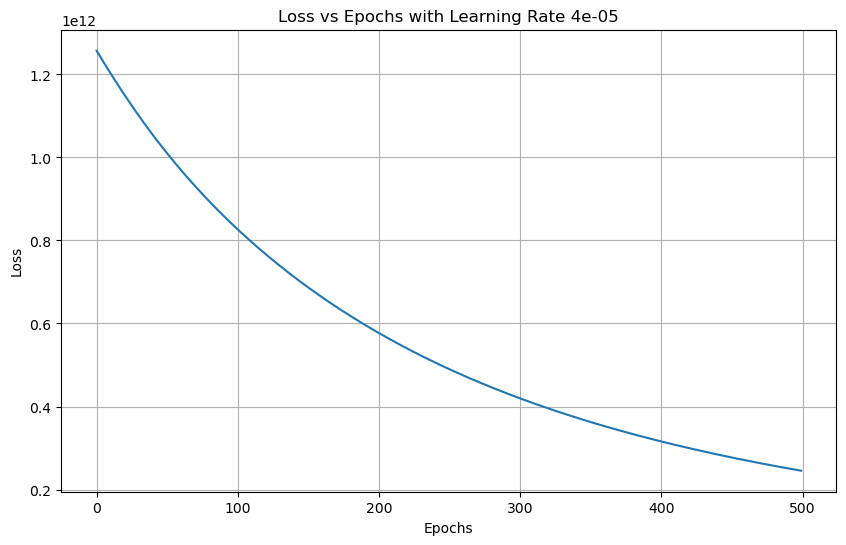

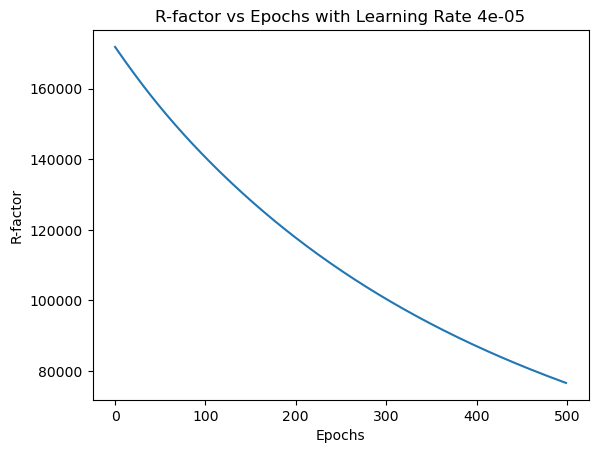

302
r_factor_metric called
Best R-factor for learning rate 4e-05: 7.656e+04


In [16]:
lr = [4e-5]
best_pars_overall = None
best_rf_overall = np.inf
best_loss_overall = []

for learning_rate in lr:
    time_start = time()
    print(f"Learning rate: {learning_rate}")
    optim = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    path_max_mode_amps = path + '/PBCO_1_3_' + structure_type + '_max_bound_vectors.txt'
    max_mode_amps = np.loadtxt(path_max_mode_amps, dtype=np.float32 , delimiter=',')
    
    # indices_to_zero = [2 , 5 , 6 , 10 , 11 ,12,  13 , 14 , 18 , 19 ,22 , 23 , 38 , 43 , 4 , 17 , 19 , 46 , 1 , 7 , 35 , 44 , 49 , 16 , 24 , 28 , 45]
    # # indices_to_zero = np.arange(1, mode_num+1)
    # or index in indices_to_zero:
    #     max_mode_amps[index - 1] = 0.0

    max_mode_amps = tf.convert_to_tensor(max_mode_amps, dtype=tf.float32)

    n_epochs = 500
    histories = []
    n_iter = 1

    min_loss = np.inf
    best_pars = None
    # List to store the loss values for each epoch
    all_losses = []
    all_rfs = []

    for i in range(n_iter):
        # Create the model
        inputs = tf.keras.Input(shape=(n_dim,))
        outputs = FunAsLayer(matrix , max_mode_amps)(inputs)
        model = tf.keras.Model(inputs, outputs)

        initial_weights = model.layers[-1].get_weights()[0]

        # Compile the model with the custom loss function and metric
        model.compile(
            optimizer=optim,
            loss= 'mse', # MSE_weighted() if using errors
            metrics=[r_factor_metric],
            run_eagerly=False,  # Set to True for debugging, False for performance

        )
        
        history = model.fit(
        x=features,
        y=labels,  # replace with combined_labels if using errors
        batch_size = features.shape[0], # Use a smaller batch size features.shape[0]
        epochs=n_epochs,
        verbose=0,
        shuffle=True, # not sure whether this matters
        # callbacks=[cb]
        sample_weight=labels_err  # Use sample weights if you have errors
        )

        histories.append(history)
        all_losses.append(history.history['loss'])
        all_rfs.append(history.history['r_factor_metric'])

        # Check final loss
        final_loss = history.history['loss'][-1]
        print(model.layers[-1].get_weights()[0].shape)
        curren_model_pars = max_mode_amps * tf.tanh(model.layers[-1].get_weights()[0])

        print(f"Final loss: {final_loss:.3e}")

        if final_loss < min_loss:
            # Update best model parameters
            best_model_pars = max_mode_amps * tf.tanh(model.layers[-1].get_weights()[0])
            min_loss = final_loss
            rf = r_factor_metric(labels, fun_tf(features, best_model_pars , matrix))
            print(f"Iteration {i+1} - New best loss: {min_loss:.3e} (R-factor: {rf:.3e})")

    if min_loss < best_rf_overall:
        best_rf_overall = min_loss
        best_pars_overall = best_model_pars
        best_loss_overall = all_losses
    print(f"time elapsed: {time() - time_start:.2f} seconds")
    print(f"With {n_epochs*n_iter /(time() - time_start)} iterations per second")
    # Plotting the loss values
    plt.figure(figsize=(10, 6))

    # Plot the loss values for each iteration
    for i, loss_values in enumerate(all_losses):
        plt.plot(loss_values, label=f'Iteration {i+1}')
    
    plt.title(f'Loss vs Epochs with Learning Rate {learning_rate}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    # plt.legend()
    plt.grid(True)
    plt.show()

    for i , rf_values in enumerate(all_rfs):
        plt.plot(rf_values, label=f'R-factor Iteration {i+1}')
    
    plt.title(f'R-factor vs Epochs with Learning Rate {learning_rate}')
    plt.xlabel('Epochs')
    plt.ylabel('R-factor')
    plt.show()

    y_pred = fun_tf(features, best_model_pars , matrix)
    labels = tf.reshape(labels, [-1])
    rf = r_factor_metric(labels, y_pred)
    print(f"Best R-factor for learning rate {learning_rate}: {rf:.3e}")
    final_weights = model.layers[-1].get_weights()[0]

In [17]:
all_losses = best_loss_overall
best_model_pars = best_pars_overall
min_loss = best_rf_overall

print(f"min loss: {min_loss}")
print(f"r_factor: {rf}")

# # Plotting the loss values
# plt.figure(figsize=(10, 6))

# # Plot the loss values for each iteration
# for i, loss_values in enumerate(all_losses):
#     plt.plot(loss_values, label=f'Iteration {i+1}')

# plt.title('Loss vs Epochs')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# # plt.legend()
# plt.grid(True)
# plt.show()

min loss: 245357723648.0
r_factor: 76564.453125


C:\Users\User\AppData\Local\Temp\ipykernel_23912\3422540335.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,b;a,b)[Pr1:h:dsp]B3u(a) : -0.01037010
mode a2 Pmmm[1/3,1/3,0]V1(a,b;a,b)[Pr1:h:dsp]B3u(b) : -0.00821329
mode a3 Pmmm[1/3,1/3,0]V1(a,b;a,b)[Pr1:h:dsp]B2u(a) : 0.01441654
mode a4 Pmmm[1/3,1/3,0]V1(a,b;a,b)[Pr1:h:dsp]B2u(b) : -0.03893797
mode a5 Pmmm[0,0,0]GM3-(a)[Pr1:h:dsp]B3u(a) : 0.00840333
mode a6 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.07599845
mode a7 Pmmm[0,1/3,0]DT4(a,0)[Pr1:h:dsp]B3u(a) : -0.04327168
mode a8 Pmmm[1/3,0,0]SM1(a,b)[Pr1:h:dsp]B3u(a) : 0.00167530
mode a9 Pmmm[1/3,0,0]SM1(a,b)[Pr1:h:dsp]B3u(b) : -0.07618309
mode a10 Pmmm[1/3,1/3,0]V1(a,b;a,b)[Ba1:t:dsp]A1(a) : 0.05477147
mode a11 Pmmm[1/3,1/3,0]V1(a,b;a,b)[Ba1:t:dsp]A1(b) : 0.03672077
mode a12 Pmmm[1/3,1/3,0]V1(a,b;a,b)[Ba1:t:dsp]B2(a) : -0.13169903
mode a13 Pmmm[1/3,1/3,0]V1(a,b;a,b)[Ba1:t:dsp]B2(b) : 0.03937456
mode a14 Pmmm[1/3,1/3,0]V1(a,b;a,b)[Ba1:t:dsp]B1(a) : -0.00541328
mode a15 Pmmm[1/3,1/3,0]V1(a,b;a,b)[Ba1:t:dsp]B1(b) : 0.02622292
mode a16 Pmmm[0,0,0]GM

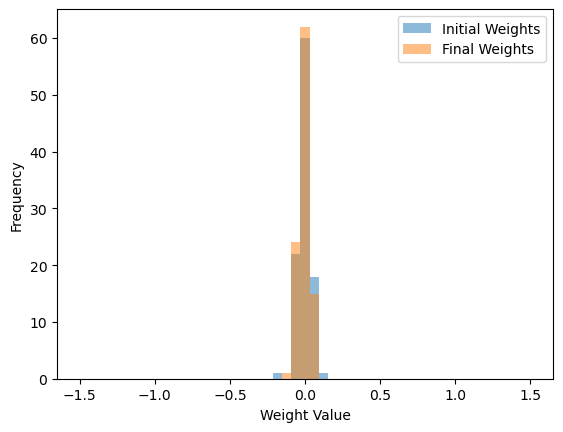

In [18]:
path_displacive_modes = path + '/PBCO_1_3_' + structure_type + '_displacive_modes.txt'

mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)
mode_names = mode_names.values.tolist()
mode_names = pd.DataFrame(mode_names)

# Print the best model parameters
print("Best model parameters:") 
for i, par in enumerate(best_model_pars):
    print(f"mode a{i+1} {mode_names.iloc[i, 1]} : {par.numpy() / max_mode_amps[i]:.8f}")

list_modes_removal = np.abs(best_model_pars.numpy()) / max_mode_amps

plt.hist(initial_weights, bins=np.linspace(-1.5 , 1.5 , 50), alpha=0.5, label='Initial Weights')
plt.hist(final_weights , bins=np.linspace(-1.5 , 1.5 , 50), alpha=0.5, label='Final Weights')
# plt.hist(best_model_pars * max_mode_amps, bins=np.linspace(-1.5 , 1.5 , 50), alpha=0.5, label='Best Weights')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [19]:
def plot_plane_sim_vs_exp_DIM3(ax, df, r_factor, l, norm_plane=False):
    exp_data_0 = df.loc[df['l'] == l].copy()
    if norm_plane == True:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 100
    
    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['normalised_exp'] + 1)* 500 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    # ax.scatter(exp_data_0['h'], exp_data_0['k'], 
    #         s=exp_data_0['intensity_sim'] * 100, color='red', edgecolor="black",
    #         label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    # ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=exp_data_0['normalised_exp'] * 100, color='blue', edgecolor="black",
    #         label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = {l} (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

def plot_plane_sim_vs_exp_DIM3_no_bragg(ax, df, r_factor, l, norm_plane=False):
    exp_data_0 = df.loc[df['l'] == l].copy()
    #copy the dataframe and remove rows where h and k are both integer
    exp_data_0 = exp_data_0[~((exp_data_0['h'] % 1 == 0) & (exp_data_0['k'] % 1 == 0))]
    if norm_plane == True:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 100

    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['normalised_exp'] + 1) * 500 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = {l} (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

def alris_r_factor(data):
    exp_intensity = data['intensity_exp'] / np.max(data['intensity_exp'])
    exp_intensity = exp_intensity / np.sum(exp_intensity) * 100
    simulated_intensity = data['intensity_sim']
    alris_r_factor = np.sum(np.abs(exp_intensity - simulated_intensity)) / np.sum(np.abs(exp_intensity))
    return alris_r_factor

302
ALRIS R-factor: 886401.682


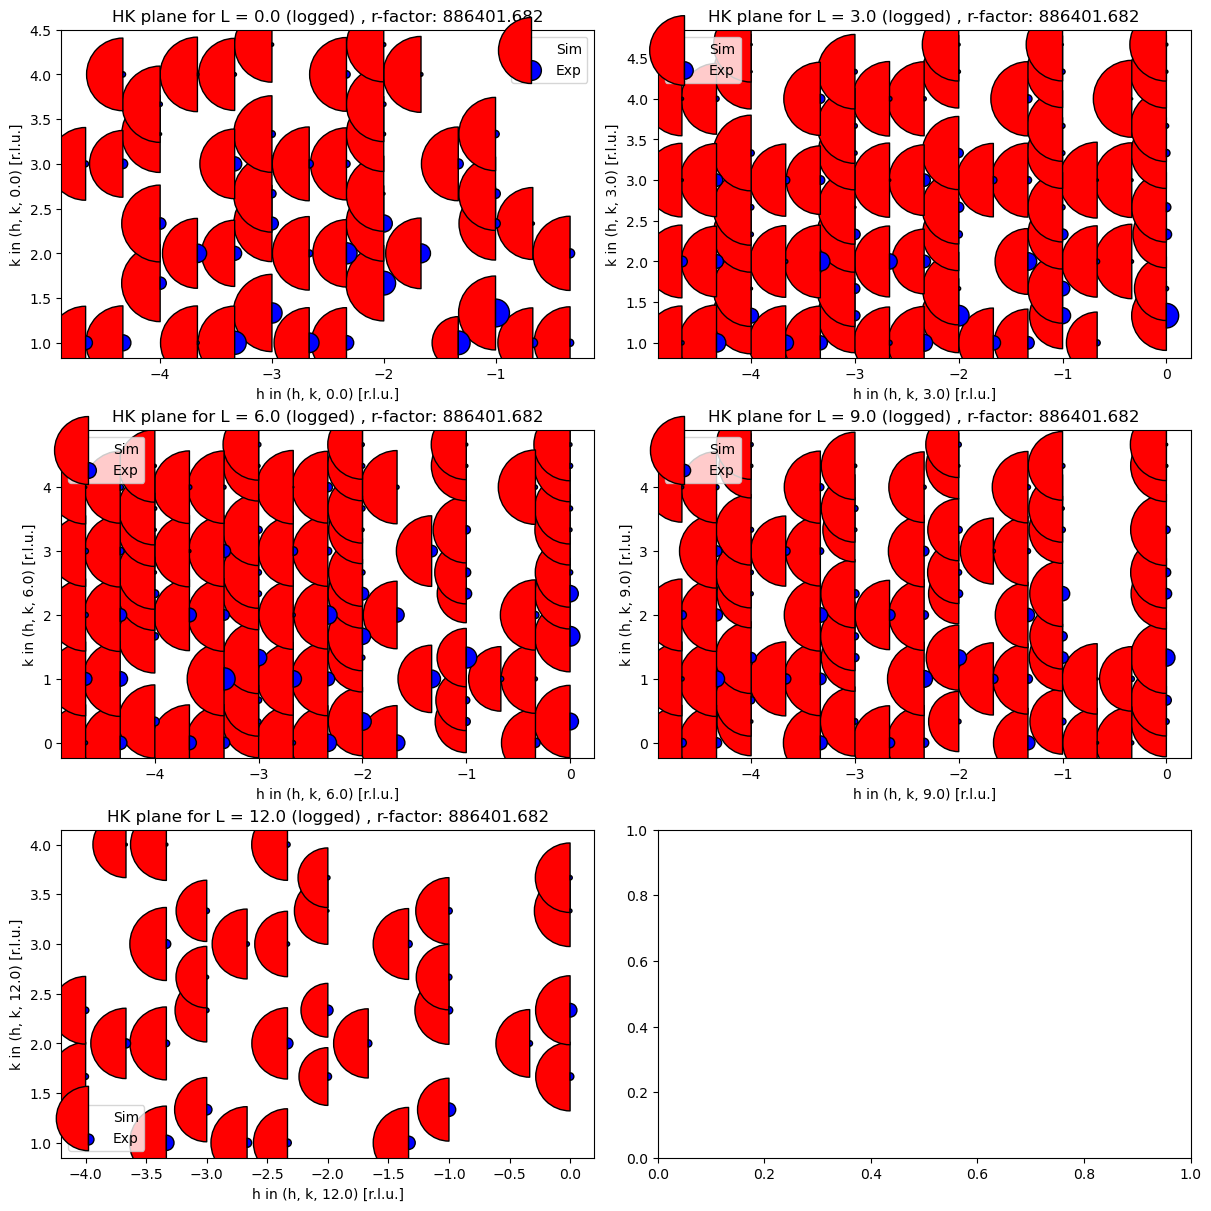

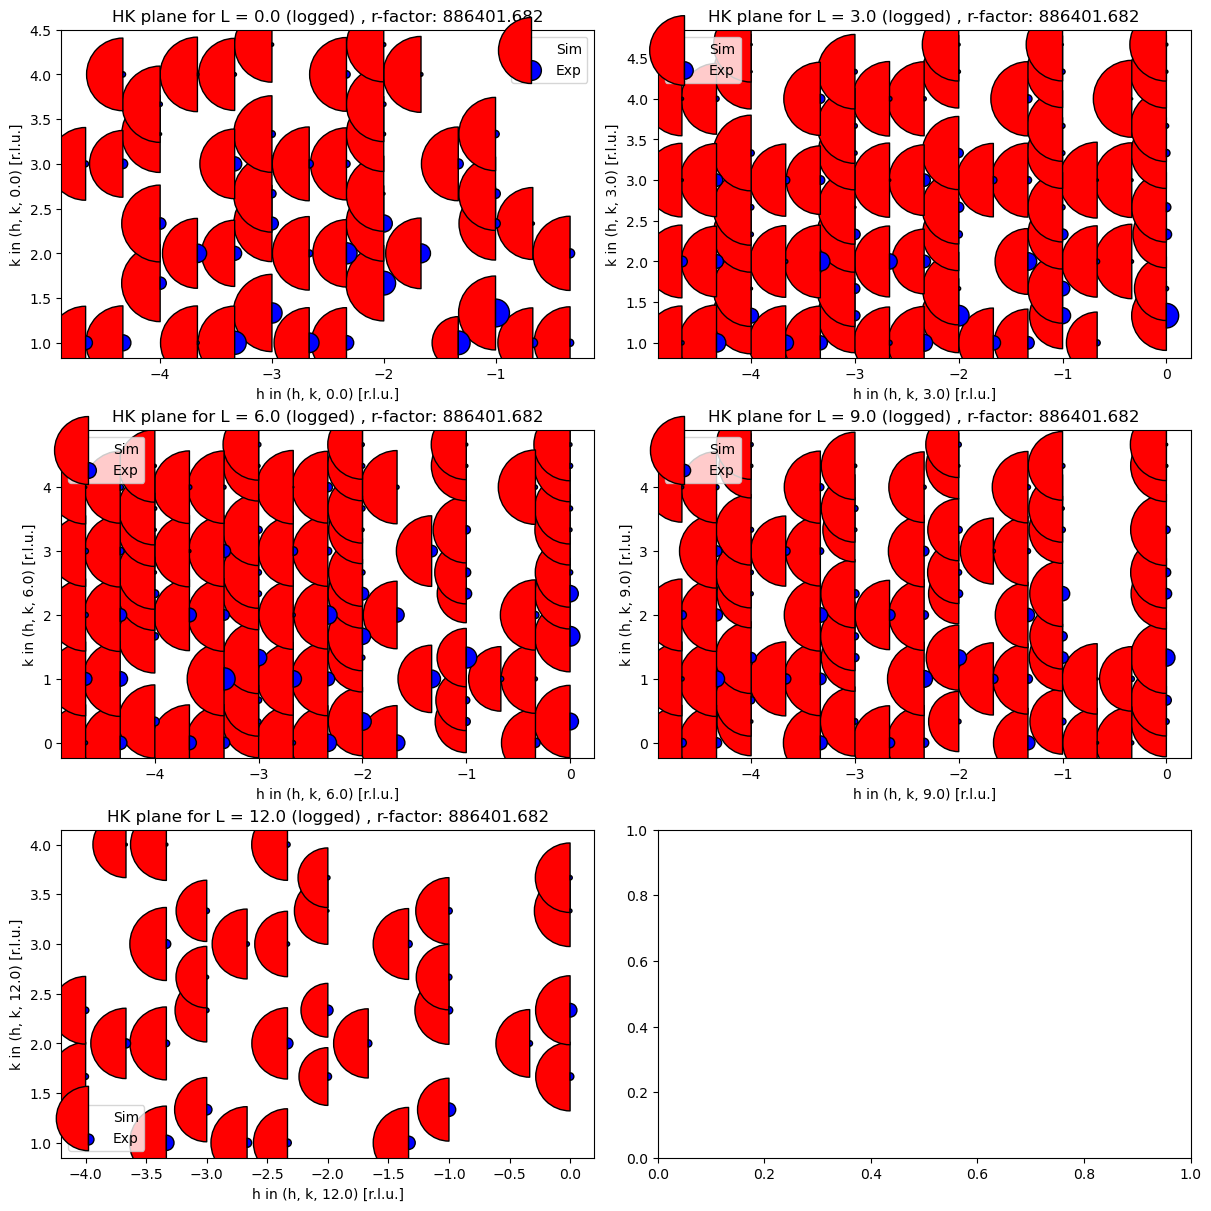

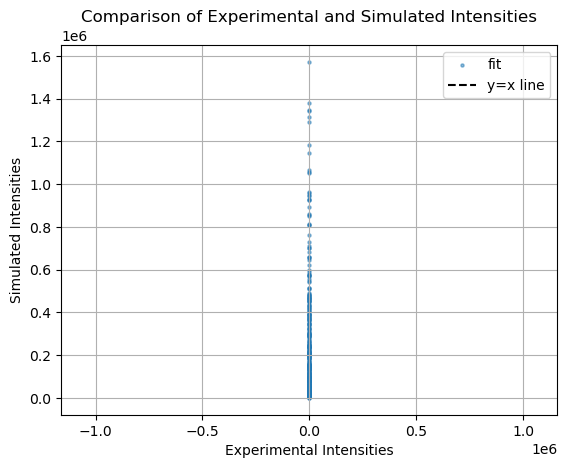

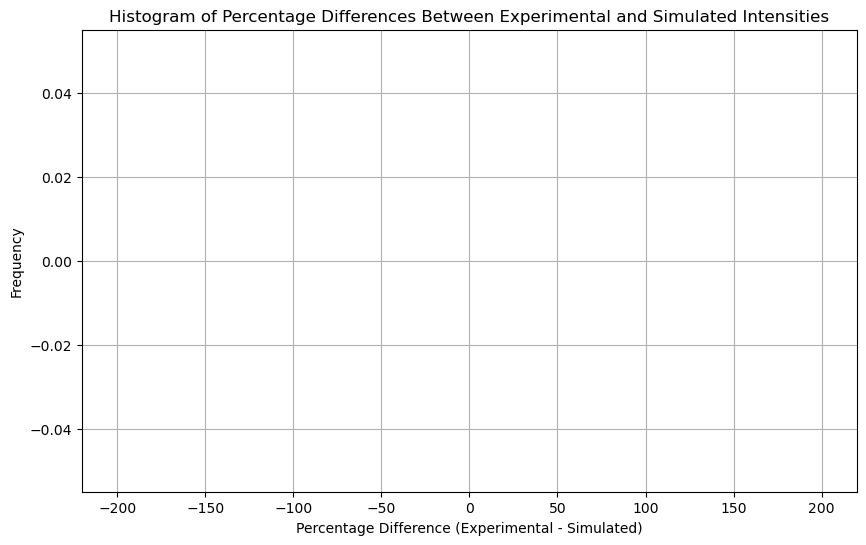

In [20]:
# # exp_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no0.csv')
# exp_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no_bragg.csv')

exp_data = experimental_data.copy()


exp_data['intensity_sim'] = fun_tf(features, best_model_pars, matrix).numpy()
r_factor = alris_r_factor(exp_data)
print(f"ALRIS R-factor: {r_factor:.3f}")

normalised_exp_data = exp_data['intensity_exp'] / np.sum(exp_data['intensity_exp']) * 100
exp_data['normalised_exp'] = normalised_exp_data
exp_data['intensity_exp_err'] = labels_err.numpy()

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()
for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3_no_bragg(axs[i], exp_data, r_factor,l, norm_plane=False)
plt.show()

normalised_exp = exp_data['intensity_exp']/np.sum(exp_data['intensity_exp']) * 100

x = np.linspace(0 ,max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()